<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões tangenciais em vigas

### Problema 1

Considere a viga fabricada com um perfil tubular, com dimensões transversais 60 $\times$ 80 mm $^2$ e com 8 mm de espessura, que está indicada na figura. No ponto C está aplicada a força $P_1$ = 5 kN numa direção paralela ao eixo $x$, no ponto D está aplicada a força $P_2$ = 15 kN também numa direção paralela ao eixo $x$ e no ponto A, a força $P_3$ = 10 kN numa direção paralela e em sentido oposto ao eixo $y$.

**a)** Determine a distribuição de tensões normais na secção que dista 250 mm da extremidade da viga, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

**b)** Obtenha o tensor das tensões nos pontos E, F, G e H localizados na secção referida na alínea a) e para o sistema de eixos indicado.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/MSII_Au06_P1.png"
width="600">


### Método de Análise

Embora existam várias formas de analisar uma estrutura submetida a cargas combinadas, o procedimento geralmente inclui os seguintes passos:

1. Selecionar um ponto na estrutura onde as tensões devem ser determinadas. Normalmente, o ponto é escolhido numa secção transversal onde as tensões são elevadas, como, por exemplo, numa secção transversal onde o momento flector atinge o seu valor máximo.

2. Para cada carga na estrutura, determinar os esforços internos na secção transversal que contém o ponto selecionado. Esses esforços podem incluir o esforço axial ($N$), os esforços transversos ($V_y, V_z$), os momentos fletores ($M_y, M_z$) e o momento de torção ($M_x \equiv T$), em relação ao referencial cartesiano principal de inércia da secção, com origem no centroide da área de secção.

3. Calcular as tensões normais e de corte no ponto selecionado devido a cada um dos esforços internos resultantes. As tensões são diretamente determinadas a partir das fórmulas de tensão derivadas para a flexão e torção de elementos elásticos: $σ = \frac{P}{A}$, $\tau = \frac{T}{2A_0t}$, $σ = \frac{My}{I}$, $τ = \frac{VQ}{Ib}$.

4. Combinar as componentes de tensão para obter a matriz do tensor de tensões no ponto selecionado, levando em consideração os sentidos positivos para essas componentes em relação aos eixos do sistema de coordenadas.
    
### Sistema força-binário equivalente

- Membro ABDE submetido a um sistema de forças.
- Diagrama de corpo livre do segmento ABC, usado para determinar as forças internas e momentos na secção transversal C.
- Forças e momentos internos separados em: (a) as forças e momentos que geram tensões normais e (b) forças e momentos que tão origem a tensões de corte.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/FBequivalente.png"
width="800">



### Resolução

#### **a)** Determine a distribuição de tensões normais na secção que dista 250 mm da extremidade da viga, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

In [61]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
class varin: pass
d = varin()
d.tub_b = 60.*1e-3  # unit: m
d.tub_h = 80.*1e-3 # unit: m
d.tub_e = 8.*1e-3 # unit: m
d.xL = 250.e-3 # unit: m
d.P1 = 5.*1e3 # unit: N/m
d.P2 = 15.*1e3 # unit: N/m
d.P3 = 10.*1e3 # unit: N/m

####  Sistema de força-binário equivalente

Importa salientar que, para a análise das componentes de tensão de corte originadas pelos esforços transversais $V_y$ e $V_z$, bem como pelo momento de torção, $M_x \equiv T$, geralmente é mais conveniente considerar a resultante dos esforços internos como resultante do sistema de força-binário equivalente às forças externas.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/rFBEquiv_v2.png"
width="600">

- Esforço axial, $N$

\begin{equation*}
x:~\rightarrow(+)  ~ \Rightarrow ~
N = P_1 + P_2
\end{equation*}

In [62]:
N = d.P1 + d.P2
print(f'N = {N*1e-3:.1f} [kN]')

N = 20.0 [kN]


- Esforço tranverso, $V_y$
 
\begin{equation*}
y:~\uparrow(+) ~ \Rightarrow ~
V_y = -P_3
\quad\vee\quad
V_y = P_3 \downarrow
\end{equation*}

In [63]:
Vy = -d.P3
print(f'Vy = {Vy*1e-3:.1f} \u2261 {np.abs(Vy*1e-3):.1f} \u2193 [kN]')

Vy = -10.0 ≡ 10.0 ↓ [kN]


- Esforço tranverso, $V_z$

\begin{equation*}
z:~\swarrow (+) ~ \Rightarrow ~
V_z = 0
\end{equation*}

In [64]:
Vz = 0
print(f'Vz = {Vz:.1f} [kN]')

Vz = 0.0 [kN]


- Momento de torção em torno do eixo $x$, $M_x$

Só exercem momento segundo a direção $x$ as forças que estão contidas num plano perpendicular a este eixo. Neste caso, apenas a força vertical $\vec{P}_3$ exerce momento em $x$.

\begin{equation*}
x-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_x = - P_3 \cdot (b/2)
\quad\vee\quad
M_x = P_3 \cdot (b/2)
\circlearrowright
\end{equation*}

com $\vec{P}_3 = -P_3~\vec{\jmath} ~\wedge~\vec{r}_{\vec{P_3}} = -b/2~\vec{k} \quad\therefore\quad \vec{M_x}^{(P_3)} = \begin{vmatrix}
\vec{\imath} & \vec{\jmath} & \vec{k} \\
0 & 0 & -b/2 \\
0 & -P_3 & 0
\end{vmatrix} = - P_3 (b/2)~\vec{\imath}$

In [65]:
Mx = -d.P3*d.tub_b/2
print(f'Mx = {Mx*1e-3:.1f} \u2261 {np.abs(Mx*1e-3):.1f} \u21BB [kN.m]')

Mx = -0.3 ≡ 0.3 ↻ [kN.m]


- Momento fletor em torno do eixo $y$, $M_y$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular. Neste caso, ambas as forças $\vec{P}_1$ e $\vec{P}_2$ contribuem para $M_y$.

\begin{equation*}
y-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_y = P_1 \cdot b/2 - P_2 \cdot b/2
\quad(M_y \circlearrowright)
\end{equation*}

com

- $\vec{P}_1 = P_1~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_1}} = b/2~\vec{k}$
- $\vec{P}_2 = P_2~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_2}} = -b/2~\vec{k}$

ou seja,

\begin{equation*}
\vec{M_y}^{(P_1, P_2)} = \begin{vmatrix}
\vec{\imath} & \vec{\jmath} & \vec{k} \\
0 & 0 & b/2 \\
P_1 & 0 & 0
\end{vmatrix} + \begin{vmatrix}
\vec{\imath} & \vec{\jmath} & \vec{k} \\
0 & 0 & -b/2 \\
P_2 & 0 & 0
\end{vmatrix} = ( P_1 \cdot b/2 - P_2 \cdot b/2)~\vec{\jmath}
\end{equation*}

In [66]:
My = d.P1*d.tub_b/2 - d.P2*d.tub_b/2
print(f'My = {My*1e-3:.1f} \u2261 {np.abs(My*1e-3):.1f} \u21BB [N.m]')

My = -0.3 ≡ 0.3 ↻ [N.m]


- Momento fletor em torno do eixo $z$, $M_z$

Todas as forças exercem momento fletor segundo o eixo $z$, pois $\vec{P}_1$, $\vec{P}_2$ e $\vec{P}_3$ estão orientadas no plano $x-y$, perpendicular a $z$.

\begin{equation*}
z-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_z = P_1 \cdot h/2 + P_2 \cdot h/2 - P_3 \cdot x_L
\quad (M_z \circlearrowright) 
\end{equation*}

com

- $\vec{P}_1 = P_1~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_1}} = -h/2~\vec{\jmath} \quad\therefore\quad \vec{M_z}^{(P_1)} = P_1 (h/2)~\vec{k}$
- $\vec{P}_2 = P_2~\vec{\imath} ~\wedge~\vec{r}_{\vec{P_2}} = -h/2~\vec{k} \quad\therefore\quad \vec{M_z}^{(P_2)} = P_2 (h/2)~\vec{k}$
- $\vec{P}_3 = -P_3~\vec{\jmath} ~\wedge~\vec{r}_{\vec{P_2}} = x_L~\vec{\imath} \quad\therefore\quad \vec{M_z}^{(P_3)} = - P_3 x_L~\vec{k}$

In [67]:
Mz = d.P1*d.tub_h/2 + d.P2*d.tub_h/2 - d.P3*d.xL
print(f'Mz = {Mz*1e-3:.1f} \u2261 {np.abs(Mz*1e-3):.1f} \u21BB [N.m]')

Mz = -1.7 ≡ 1.7 ↻ [N.m]


### Propriedades de área da secção

- Área da secção

In [68]:
Ae = d.tub_b*d.tub_h
Ai = (d.tub_b-2*d.tub_e)*(d.tub_h-2*d.tub_e)
A = Ae - Ai 
print(f'A = Ae - Ai :: {Ae:.3e} - {Ai:.3e} = {A:.3e} [m^2]')

A = Ae - Ai :: 4.800e-03 - 2.816e-03 = 1.984e-03 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

Nota: na expressão $I_i = bh³/12$, a dimensão ao cubo ($h³$) é sempre uma dimensão perpendicular ao eixo em análise $i$.

In [69]:
def irect(b,h): return b*h**3/12

Ize = irect(d.tub_b,d.tub_h)
Izi = irect(d.tub_b-2*d.tub_e,d.tub_h-2*d.tub_e)
Iz = Ize - Izi 
print(f'Iz = Ize - Izi :: {Ize:.3e} - {Izi:.3e} = {Iz:.3e} [m^4]')

Iz = Ize - Izi :: 2.560e-06 - 9.612e-07 = 1.599e-06 [m^4]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [70]:
Iye = irect(d.tub_h,d.tub_b)
Iyi = irect(d.tub_h-2*d.tub_e,d.tub_b-2*d.tub_e)
Iy = Iye - Iyi
print(f'Iy = Iye - Iyi :: {Iye:.3e} - {Iyi:.3e}  = {Iy:.3e} [m^4]')

Iy = Iye - Iyi :: 1.440e-06 - 4.543e-07  = 9.857e-07 [m^4]


#### Esforço combinado

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeitos de concentração local de tensões) podem ser calculadas, considerando também o princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx}(z,y) = \pm \frac{N}{A} \mp \frac{M_z}{I_z}y \pm \frac{M_y}{I_y} z
\end{equation*}

É de notar que apenas os esforços $N$, $M_z$ e $M_y$ exercem tensões normais:

- $N$: As forças $P_1$ e $P_2$ exercem uma força de tração ao longo do eixo longitudinal $x$ da viga.

- $M_z$: De acordo com o sistema força-binário equivalente determinado na secção de interesse, o momento fletor em torno de $z$ é negativo. De facto, pode-se concluir que a força $P_3$ tem o efeito de fletir a viga, causando tração nas fibras superiores ao eixo neutro.

- $M_y$: Ao considerar o equilíbrio dos momentos em torno do eixo $y$ associado às forças $P_1$ e $P_2$, percebe-se, pela regra da mão direita, que a viga tende a fletir de tal forma que as fibras na face que contém o ponto $H$ estão sob tração, gerando por um momento resultante negativo $M_y$.

Desta forma resulta,

\begin{equation*}
\sigma_{xx}(z,y) = \frac{|N|}{A} + \frac{|M_z|}{I_z}y - \frac{|M_y|}{I_y} z
\end{equation*}


In [71]:
def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

y, z, sigx = sy.symbols('y z sigx')

sec_hand_expr = N/A + np.abs(Mz)/Iz*y - np.abs(My)/Iy*z
Eq = sigx - sec_hand_expr
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(z,y)  = {printsymSF(sigxx*1e-6)} [MPa]')

sigxx(z,y)  = 1063.294*y - 304.357*z + 10.081 [MPa]


In [72]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

zsiz = np.linspace(d.tub_b/2,-d.tub_b/2)
ysiz = np.linspace(d.tub_h/2,-d.tub_h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(z2,y2):
    return sigxx.subs({(z,z2),(y,y2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(zsiz[j],ysiz[i])

yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

y = 0.286239541267118*z - 0.00948058191018342 (recta geométrica do eixo neutro) [m]
z = 3.49357742670082*y + 0.0331211469534049 (recta geométrica do eixo neutro) [m]


Na função $y = f(z)$, o coeficiente associado à ordenada $z$ é positivo. Isso significa que, à medida que $z$ aumenta, o valor de $y$ também cresce, descrevendo uma reta com declive positivo.

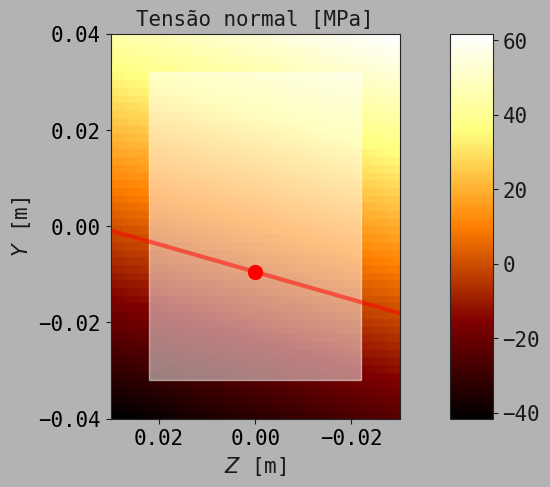

In [73]:
zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2,d.tub_h/2], cmap="afmhot")
ax.add_patch(Rectangle((-d.tub_b/2+d.tub_e, -d.tub_h/2+d.tub_e), d.tub_b-2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [74]:
zmax_ , ymax_, = -d.tub_b/2, d.tub_h/2
sigmax_ = tensnormal(zmax_, ymax_)
print(f'sig.max(z,y) :: sig.max({zmax_},{ymax_}) = {sigmax_*1e-6:.2f} [MPa]')

zmin_, ymin_ = d.tub_b/2, -d.tub_h/2
sigmin_ = tensnormal(zmin_,ymin_)
print(f'sig.min(z,y) :: sig.min({zmin_},{ymin_}) = {sigmin_*1e-6:.2f} [MPa]')

sig.max(z,y) :: sig.max(-0.03,0.04) = 61.74 [MPa]
sig.min(z,y) :: sig.min(0.03,-0.04) = -41.58 [MPa]


In [87]:
# ============================================================================
# INTERACTIVE NOTEBOOK CELL
# ============================================================================
# Install ipywidgets if needed (uncomment to run)
# !pip install ipywidgets

from ipywidgets import interact, FloatSlider, Output
import ipywidgets as widgets

# Create interactive sliders
P1_slider = FloatSlider(value=5.0, min=-20.0, max=20.0, step=0.5,
                        description='P₁ [kN]', style={'description_width': '100px'})
P2_slider = FloatSlider(value=15.0, min=-20.0, max=20.0, step=0.5,
                        description='P₂ [kN]', style={'description_width': '100px'})
P3_slider = FloatSlider(value=10.0, min=-20.0, max=20.0, step=0.5,
                        description='P₃ [kN]', style={'description_width': '100px'})

output_widget = Output()

def update_stress_plot(P1_kN, P2_kN, P3_kN):
    """Update stress distribution with interactive loads"""

    # Convert kN to N
    P1_N, P2_N, P3_N = P1_kN*1e3, P2_kN*1e3, P3_kN*1e3

    # ====== INTERNAL FORCES & MOMENTS ======
    # Sign conventions: +X rightward, +Y upward, +Z leftward

    N = P1_N + P2_N                              # Normal force (axial)
    Vy = -P3_N                                    # Shear in Y (transverse)
    Vz = 0                                        # Shear in Z (no load)
    Mx = -P3_N * d.tub_b / 2                     # Torsional moment
    My = P1_N * d.tub_b / 2 - P2_N * d.tub_b / 2 # Bending moment about Y
    Mz = P1_N * d.tub_h / 2 + P2_N * d.tub_h / 2 - P3_N * d.xL  # Bending moment about Z

    # ====== RECALCULATE STRESS ======
    y_sym, z_sym, sigx_sym = sy.symbols('y z sigx')

    # Stress formula: σ_xx = N/A + |Mz|/Iz*y - |My|/Iy*z
    sec_hand_expr = N/A - Mz/Iz*y + My/Iy*z
    Eq_new = sigx_sym - sec_hand_expr
    sigxx_new = solve(Eq_new, sigx_sym)[0]

    # ====== STRESS MAP ======
    def tensnormal_new(z_val, y_val):
        return float(sigxx_new.subs({z_sym: z_val, y_sym: y_val}))

    SxxMap_new = np.zeros(np.shape(Z))
    for i in range(len(ysiz)):
        for j in range(len(zsiz)):
            SxxMap_new[i, j] = tensnormal_new(zsiz[j], ysiz[i])

    # ====== NEUTRAL AXIS ======
    yzfun_new = solve(sigxx_new, y_sym)[0]
    zplo_new = zsiz
    yplo_new = np.array([float(yzfun_new.subs(z_sym, zval)) for zval in zplo_new])

    # Extreme stresses
    # Check all four corners to find true maximum and minimum
    corner_stresses = [
        tensnormal_new(-d.tub_b/2, d.tub_h/2),   # LEFT-TOP
        tensnormal_new(d.tub_b/2, d.tub_h/2),    # RIGHT-TOP
        tensnormal_new(-d.tub_b/2, -d.tub_h/2),  # LEFT-BOTTOM
        tensnormal_new(d.tub_b/2, -d.tub_h/2)    # RIGHT-BOTTOM
    ]

    sigma_max = max(corner_stresses)
    sigma_min = min(corner_stresses)
    center_y = float(yzfun_new.subs(z_sym, 0))

    # ====== PLOTTING ======
    with output_widget:
        output_widget.clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: Stress distribution
        ax1.set_title('Normal Stress Distribution [MPa]', fontsize=14, fontweight='bold')
        ax1.set_ylabel(r'$Y$ [m]', fontsize=12)
        ax1.set_xlabel(r'$Z$ [m]', fontsize=12)

        im = ax1.imshow(SxxMap_new*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2, d.tub_h/2],
               cmap="afmhot")

        # Draw tube outline
        ax1.add_patch(Rectangle((-d.tub_b/2+d.tub_e, -d.tub_h/2+d.tub_e),
                               d.tub_b-2*d.tub_e, d.tub_h-2*d.tub_e,
                               color="white", alpha=0.3, linewidth=2))

        # Plot neutral axis
        valid_mask = np.isfinite(yplo_new)
        ax1.plot(zplo_new[valid_mask], yplo_new[valid_mask], 'r-', linewidth=3,
                label='Neutral axis', alpha=0.7)
        ax1.plot(0, center_y, 'o', color='red', markersize=10, alpha=0.8)

        divider = make_axes_locatable(ax1)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(im, cax=cax, orientation="vertical")
        cbar.set_label('Stress [MPa]', fontsize=11)
        ax1.grid(True, alpha=0.2)
        ax1.legend(loc='upper left', fontsize=10)

        # Right: Summary
        ax2.axis('off')
        summary_text = f"""
            APPLIED LOADS:
              P₁ = {P1_kN:>8.2f} kN    P₂ = {P2_kN:>8.2f} kN    P₃ = {P3_kN:>8.2f} kN

            INTERNAL FORCES (@ x = {d.xL*1000:.0f} mm):
              N  = {N*1e-3:>8.2f} kN  (positive = tension)
              Vy = {Vy*1e-3:>8.2f} kN  (positive = upward)
              Vz = {Vz*1e-3:>8.2f} kN  (positive = leftward)

            INTERNAL MOMENTS (@ x = {d.xL*1000:.0f} mm):
              Mx = {Mx*1e-3:>8.3f} kN·m  (torsion)
              My = {My*1e-3:>8.3f} kN·m  (bending about Y)
              Mz = {Mz*1e-3:>8.3f} kN·m  (bending about Z)

            STRESS EXTREMA:
              σ_max = {sigma_max*1e-6:>8.2f} MPa (tension)
              σ_min = {sigma_min*1e-6:>8.2f} MPa (compression)
              Δσ    = {(sigma_max - sigma_min)*1e-6:>8.2f} MPa

            NEUTRAL AXIS:
              @ z = 0: y = {center_y*1000:>7.2f} mm
        """

        ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes,
                fontfamily='monospace', fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        plt.tight_layout()
        plt.show()

# Create interactive plot - interact() will display sliders automatically
def interactive_update(P1_kN, P2_kN, P3_kN):
    update_stress_plot(P1_kN, P2_kN, P3_kN)

# Display once with interact
interact_manual = interact(
    interactive_update,
    P1_kN=P1_slider,
    P2_kN=P2_slider,
    P3_kN=P3_slider
)

# Display output widget below
display(output_widget)

print("\n" + "="*70)
print("INTERACTIVE LOAD ANALYSIS - READY TO USE")
print("="*70)
print("Adjust the sliders above to change P₁, P₂, P₃ loads dynamically")
print("The stress map and neutral axis will update automatically")
print("\nSIGN CONVENTIONS:")
print("  • +X: along beam (→)")
print("  • +Y: upward (↑)")
print("  • +Z: leftward (←)")
print("  • +Moments: counterclockwise (⟲)")
print("="*70 + "\n")

interactive(children=(FloatSlider(value=5.0, description='P₁ [kN]', max=20.0, min=-20.0, step=0.5, style=Slide…

Output()


INTERACTIVE LOAD ANALYSIS - READY TO USE
Adjust the sliders above to change P₁, P₂, P₃ loads dynamically
The stress map and neutral axis will update automatically

SIGN CONVENTIONS:
  • +X: along beam (→)
  • +Y: upward (↑)
  • +Z: leftward (←)
  • +Moments: counterclockwise (⟲)



#### **b)** Obtenha o tensor das tensões nos pontos E, F, G e H localizados na secção referida na alínea a) e para o 
sistema de eixos indicado.

In [76]:
zE, yE = 0, d.tub_h/2
sigE = tensnormal(zE, yE)
print(f'sigxx.E ({zE},{yE})  = {sigE*1e-6:.2f} [MPa]')

zF, yF, = d.tub_b/2, 0 
sigF = tensnormal(zF, yF)
print(f'sigxx.F ({zF},{yF})  = {sigF*1e-6:.3f} [MPa]')

zG, yG = 0, -d.tub_h/2
sigG = tensnormal(zG, yG)
print(f'sigxx.G ({zG},{yG}) = {sigG*1e-6:.2f} [MPa]')

zH, yH = -d.tub_b/2, 0
sigH = tensnormal(zH, yH)
print(f'sigxx.G ({zH},{yH}) = {sigH*1e-6:.2f} [MPa]')

sigxx.E (0,0.04)  = 52.61 [MPa]
sigxx.F (0.03,0)  = 0.950 [MPa]
sigxx.G (0,-0.04) = -32.45 [MPa]
sigxx.G (-0.03,0) = 19.21 [MPa]


- Tensor das tensões num ponto material:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
\end{equation*}

No problema de flexão em estudo apenas existem tensões normais segundo a direção $x~:~\sigma_{xx}=N/A~,~\sigma_{yy}=\sigma_{zz}=0$.

A superfície em análise é perpendicular ao eixo longidutinal $x$ pelo que $\tau_{yz} = 0$, resultando:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

Acima já se determinaram as componentes de tensão normal, $\sigma_{xx}$, para cada ponto enunciado do perfil (E,F,G,H).

Resta-nos determinar as componentes de tensão de corte para esses pontos. De notar que:

- $T, V_y \longrightarrow \tau_{xy}$
- $T, (V_z = 0) \longrightarrow \tau_{xz}$

####  Análise da tensão de corte devida à torção

A tensão de corte média resultante do momento torsor, $\tau$, válida para um perfil de parede fina, é dada por:

\begin{equation*}
\tau_{xy} = \tau_{xz} \equiv \tau = \frac{|T|}{2A_0t}
\quad\wedge\quad T \equiv M_x
\end{equation*}


- O valor de $T$ é considerado em valor absoluto ($|T|$); o seu sentido (ainal) será usado para interpretar o valor de tensão de corte gerada pelo momento de torção, em relação ao sistema de coordenadas escolhido. 
- $A_0$ é a área interna definida pelo contorno da linha central da parede do perfil 
- $t$ é a espessura da parede do perfil tubular.

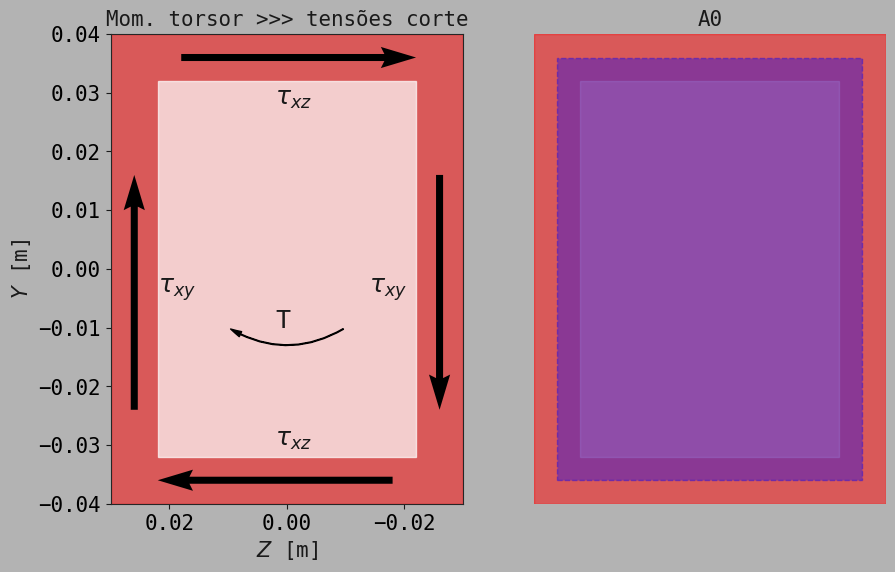

In [77]:
import matplotlib.patches as patches

fig = plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
ax  = plt.gca()
ttl = plt.title('Mom. torsor >>> tensões corte',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.7))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')

x_pos, y_pos = d.tub_b/2-d.tub_e/2, -3*d.tub_e
x_direct, y_direct = 0, 1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos-d.tub_e/2, y_pos+2.5*d.tub_e, r"$\tau_{xy}$")

x_pos, y_pos = -d.tub_b/2+d.tub_e/2, 2*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos+14*d.tub_e/4, y_pos+1.5*d.tub_e, r"$\tau_{xz}$")

x_pos, y_pos = d.tub_b/2-1.5*d.tub_e, d.tub_h/2-d.tub_e/2
x_direct, y_direct = 1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos-4*d.tub_e, y_pos-5*d.tub_e, r"$\tau_{xy}$")

x_pos, y_pos = -d.tub_b/2+1.5*d.tub_e, -d.tub_h/2+d.tub_e/2
x_direct, y_direct = -1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 1.5, width=.02)
plt.text(x_pos+2.5*d.tub_e, y_pos+.75*d.tub_e, r"$\tau_{xz}$")

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

c = patches.FancyArrowPatch((-0.01, -0.01), (0.01, -0.01),
                             connectionstyle="arc3,rad=-.3", **kw)
plt.text(0.002, -0.01,"T")
plt.gca().add_patch(c)

plt.subplot(1, 2, 2)
ax  = plt.gca()
ttl = plt.title('A0',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.axis('off')
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.2))
rectangle = ax.add_patch(Rectangle((d.tub_b/2-d.tub_e/2, -d.tub_h/2+d.tub_e/2), -d.tub_b+d.tub_e, d.tub_h-d.tub_e,color="blue",alpha=.2))
rectangle.set_linestyle("--")  # Set the linestyle for the edge (dashed line)
ax.add_patch(rectangle)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')
plt.show()

In [78]:
tor_A0 = (d.tub_h-d.tub_e)*(d.tub_b-d.tub_e)
print(f'tor_A0 = {tor_A0:.3e} [m²]')
tor_t = d.tub_e
print(f'tor_t = {tor_t:.3f} [m]')
tor_tau = np.abs(Mx)/2/tor_A0/tor_t
print(f'tor_tau = {tor_tau*1e-6:.3f} [MPa]')

tor_A0 = 3.744e-03 [m²]
tor_t = 0.008 [m]
tor_tau = 5.008 [MPa]


De notar que o momento torsor externo será localmente equilibrado: (1) nos troços horizontais do perfil, por tensões de corte $\tau_{xz}$ que têm sentido negativo no ponto E e sentido positivo no ponto G; (2) nos tramos verticais, por tensões de corte $\tau_{xy}$ que têm sentido positivo no ponto F e sentido negativo no ponto H. Em cada ponto (F, E, H, G) a tensão de corte tem a direção perpendicular à secção de corte no ponto em análise.

####  Análise da tensão de corte devida ao esforço transverso $V_y$

- Pontos E e G:
 
De notar que o esforço transverso $V_y$ é nulo nos pontos E e G: 

\begin{equation*}
\tau_{xy} = \left| \frac{V_yQ_z}{I_zt} \right| 
\quad\wedge\quad Q_z = 0 \quad\wedge\quad \tau_{xy}^{\textrm{E}} = \tau_{xy}^{\textrm{G}} = 0
\end{equation*}

Pelo que interessa analisar a tensão nos pontos F e H dos ramos verticais do perfil.

- Pontos F e H:
 
Do formulário tem-se:

\begin{equation*}
\tau_{xy} = \left| \frac{V_yQ_z}{I_zt} \right|
\quad\wedge\quad Q_z = \int_A^* y\,\mathrm{d}x = A^*\overline{y} = \sum_i A_i^*\overline{y}_i
\end{equation*}

- O valor de $V_y$ é considerado em valor absoluto ($|V_y|$); o seu sentido será usado para interpretar o valor de tensão de corte, positivo ou negativo, em relação ao sistema de coordenadas escolhido.  
- $Q_z$ é o primeiro momento de área (momento estático) em relação ao eixo $z$ de metade de secção (cortando pelos pontos F e H), e $t$ é a espessura resistente ao corte. Neste problema, o valor de $t$ será duas vezes a espessura da parede tubular fina.

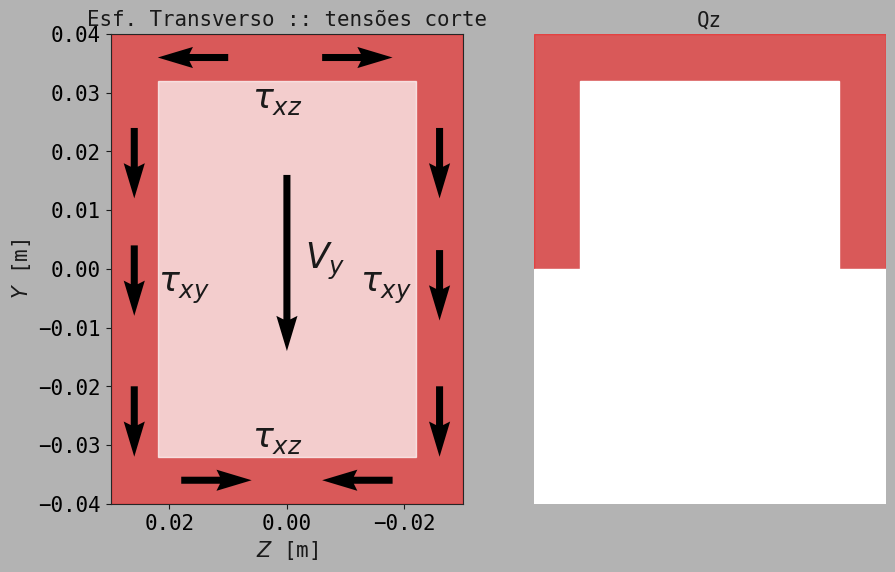

In [79]:
fig = plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
ax  = plt.gca()
ttl = plt.title('Esf. Transverso :: tensões corte',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.7))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')

x_pos, y_pos = d.tub_b/2-d.tub_e/2, -2.5*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
plt.text(x_pos-d.tub_e/2, y_pos+2.*d.tub_e, r"$\tau_{xy}$",fontsize=fzp+10)
x_pos, y_pos = d.tub_b/2-d.tub_e/2, .5*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = d.tub_b/2-d.tub_e/2, 3.*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)

x_pos, y_pos = -d.tub_b/2+d.tub_e/2, 3*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = -d.tub_b/2+d.tub_e/2, 0.4*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = -d.tub_b/2+d.tub_e/2, -2.5*d.tub_e
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)

x_pos, y_pos = d.tub_b/2-2.5*d.tub_e, d.tub_h/2-d.tub_e/2
x_direct, y_direct = -1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = d.tub_b/2-4.5*d.tub_e, d.tub_h/2-d.tub_e/2
x_direct, y_direct = 1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
plt.text(x_pos-.8*d.tub_e, y_pos-5*d.tub_e, r"$\tau_{xy}$",fontsize=fzp+10)

x_pos, y_pos = -d.tub_b/2+1.5*d.tub_e, -d.tub_h/2+d.tub_e/2
x_direct, y_direct = -1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)
x_pos, y_pos = -d.tub_b/2+6*d.tub_e, -d.tub_h/2+d.tub_e/2
x_direct, y_direct = 1, 0
ax.quiver(x_pos, y_pos, x_direct, y_direct, scale = 5, width=.02)

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

x_pos, y_pos = 0, 0
x_direct, y_direct = 0, -1
ax.quiver(x_pos, y_pos+d.tub_h*.2, x_direct, y_direct, scale=2, width=.02)
plt.text(x_pos-d.tub_b*.05, y_pos, r"$V_y$", fontsize=fzp+10)
plt.text(x_pos+d.tub_b*.1, y_pos+d.tub_h*.34, r"$\tau_{xz}$", fontsize=fzp+10)
plt.text(x_pos+d.tub_b*.1, y_pos-d.tub_h*.38, r"$\tau_{xz}$", fontsize=fzp+10)

plt.subplot(1, 2, 2)
ax  = plt.gca()
ttl = plt.title('Qz',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.axis('off')
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h,color="red",alpha=0.5))
ax.add_patch(Rectangle((d.tub_b/2-d.tub_e, -d.tub_h/2+d.tub_e), -d.tub_b+2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=1.))
ax.add_patch(Rectangle((d.tub_b/2, -d.tub_h/2), -d.tub_b, d.tub_h/2,color="white",alpha=1.))
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
cbar.ax.tick_params(labelsize=fzp)
plt.xlim([d.tub_b/2,-d.tub_b/2])
plt.ylim([-d.tub_h/2,d.tub_h/2])
ax.set_aspect('equal', 'box')

plt.show()

In [80]:
print('area superior total:')
yretmaior = d.tub_h/2/2
print(f'---\nyretmaior = {yretmaior:.3f} [m]')
Aretmaior = d.tub_h/2*d.tub_b
print(f'Aretmaior = {d.tub_h/2:.3f} x {d.tub_b:.3f} = {Aretmaior:.3e} [m²]')
Qretmaior = Aretmaior*yretmaior
print(f'Qretmaior = {Qretmaior:.3e} [m³]')
yretmenor = (d.tub_h/2-d.tub_e)/2
print(f'---\nyretmenor = {yretmenor:.3f} [m]')
Aretmenor = (d.tub_h/2-d.tub_e)*(d.tub_b-2*d.tub_e)
print(f'Aretmenor = {d.tub_h/2-d.tub_e:.3f} x {d.tub_b-2*d.tub_e:.3f} = {Aretmenor:.3e} [m²]')
Qretmenor = Aretmenor*yretmenor
print(f'Qretmenor = {Qretmenor:.3e} [m³]')
Qzret = Qretmaior - Qretmenor
print(f'---\nQzret = {Qretmaior:.3e} - {Qretmenor:.3e} = {Qzret:.3e} [m³]')

tau_Vy = np.abs(Vy*Qzret)/Iz/(2*d.tub_e)
print(f'\nVy = {np.abs(Vy):.1f} [N]')
print(f'Qz = {Qzret:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {2*d.tub_e:.3e} [m]')
print(f'>>> tau_xy_Vy = {tau_Vy*1e-6:.3f} [MPa]')

area superior total:
---
yretmaior = 0.020 [m]
Aretmaior = 0.040 x 0.060 = 2.400e-03 [m²]
Qretmaior = 4.800e-05 [m³]
---
yretmenor = 0.016 [m]
Aretmenor = 0.032 x 0.044 = 1.408e-03 [m²]
Qretmenor = 2.253e-05 [m³]
---
Qzret = 4.800e-05 - 2.253e-05 = 2.547e-05 [m³]

Vy = 10000.0 [N]
Qz = 2.547e-05 [m³]
Iz = 1.599e-06 [m⁴]
t  = 1.600e-02 [m]
>>> tau_xy_Vy = 9.957 [MPa]


In [81]:
print('metade da area superior total:')
A_mai = d.tub_h/2*d.tub_b/2
y_mai = d.tub_h/2/2
A_men = (d.tub_h/2 - d.tub_e)*(d.tub_b/2 - d.tub_e)
y_men = (d.tub_h/2 - d.tub_e)/2
Qz_ = A_mai*y_mai - A_men*y_men
print(f'(Ay)maior = ({A_mai:.3e})({y_mai:.3e}) = {A_mai*y_mai:.3e} [m³]')
print(f'(Ay)menor = ({A_men:.3e})({y_men:.3e}) = {A_men*y_men:.3e} [m³]')
print(f'Qzret (v2) = {A_mai*y_mai:.3e} - {A_men*y_men:.3e} = {Qz_:.3e} [m³]')

tau_Vy_v2 = np.abs(Vy*Qz_)/Iz/d.tub_e
print(f'\nVy = {np.abs(Vy):.1f} [N]')
print(f'Qz = {Qz_:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {d.tub_e:.3e} [m]')
print(f'>>> tau_xy_Vy (v2) = {tau_Vy_v2*1e-6:.3f} [MPa]')

metade da area superior total:
(Ay)maior = (1.200e-03)(2.000e-02) = 2.400e-05 [m³]
(Ay)menor = (7.040e-04)(1.600e-02) = 1.126e-05 [m³]
Qzret (v2) = 2.400e-05 - 1.126e-05 = 1.274e-05 [m³]

Vy = 10000.0 [N]
Qz = 1.274e-05 [m³]
Iz = 1.599e-06 [m⁴]
t  = 8.000e-03 [m]
>>> tau_xy_Vy (v2) = 9.957 [MPa]


#### Em resumo

- Tensor das tensões no ponto E, $[\sigma_E]$:

\begin{equation*}
\sigma_{xx}(z_E,y_E)
~\wedge~ \tau_{xy} = 0
~\wedge~ \tau_{xz} = -\frac{T}{2A_0t}
\end{equation*}

Importa notar que no ponto E, o momento de torção tem um sentido negativo em relação ao eixo positivo dos $z$, e que a tensão de corte $\tau_{xz}$ é medida positivamente no sentido positivo de $z$.

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_E] =
\begin{bmatrix}
\sigma_{xx}(z_E,y_E) & 0 & -\displaystyle\frac{T}{2A_0t} \\
0 & 0 & 0 \\
-\displaystyle\frac{T}{2A_0t} & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [82]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]], np.float64)

ttE = tenstens(sigE,0,-tor_tau,0,0,0)
print(f"ttE :: \n {np.array2string(ttE*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttE :: 
 [[52.61  0.00 -5.01]
 [ 0.00  0.00  0.00]
 [-5.01  0.00  0.00]] [MPa]


- Tensor das tensões no ponto G, $[\sigma_G]$:

\begin{equation*}
\sigma_{xx}(z_G,y_G)
~\wedge~ \tau_{xy} = 0
~\wedge~ \tau_{x
z} = \frac{T}{2A_0t}
\end{equation*}

Importa notar que no ponto G, o momento de torção tem um sentido positivo em relação ao eixo positivo dos $z$, e, consequentemente, a componente de tensão de corte $\tau_{xz}$ devida ao momento de torção é positiva.

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_G] =
\begin{bmatrix}
\sigma_{xx}(z_G,y_G) & 0 & \displaystyle\frac{T}{2A_0t} \\
0 & 0 & 0 \\
\displaystyle\frac{T}{2A_0t} & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [83]:
ttG = tenstens(sigG,0,tor_tau,0,0,0)
print(f"ttG :: \n {np.array2string(ttG*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttG :: 
 [[-32.45   0.00   5.01]
 [  0.00   0.00   0.00]
 [  5.01   0.00   0.00]] [MPa]


- Tensor das tensões no ponto F, $[\sigma_F]$:

\begin{equation*}
\sigma_{xx}(z_F,y_F)
~\wedge~ \tau_{xy} = \frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}
~\wedge~ \tau_{xz} = 0
\end{equation*}

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_F] =
\begin{bmatrix}
\sigma_{xx}(z_F,y_F) & \left(\displaystyle\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}\right)  & 0\\
\left(\displaystyle\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}\right)  & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [84]:
ttF = tenstens(sigF,tor_tau-tau_Vy,0,0,0,0)
print(f"ttE :: \n {np.array2string(ttF*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttE :: 
 [[ 0.95 -4.95  0.00]
 [-4.95  0.00  0.00]
 [ 0.00  0.00  0.00]] [MPa]


- Tensor das tensões no ponto H, $[\sigma_H]$:

\begin{equation*}
\sigma_{xx}(z_H,y_H)
~\wedge~ \tau_{xy} = -\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}
~\wedge~ \tau_{xz} = 0
\end{equation*}

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_H] =
\begin{bmatrix}
\sigma_{xx}(z_H,y_H) & \left(-\displaystyle\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}\right)  & 0\\
\left(-\displaystyle\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt}\right) & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [85]:
ttH = tenstens(sigH,-tor_tau-tau_Vy,0,0,0,0)
print(f"ttH :: \n {np.array2string(ttH*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttH :: 
 [[ 19.21 -14.97   0.00]
 [-14.97   0.00   0.00]
 [  0.00   0.00   0.00]] [MPa]


# Apendix - Thin-Walled Hollow Shafts

### Overview

In thin-walled hollow noncircular shafts, a good approximation of the distribution of stresses in the shaft can be obtained by a simple computation. Consider a hollow cylindrical member of noncircular section subjected to a torsional loading.

### Key Assumptions

- The thickness is assumed to remain small compared to the other dimensions of the member
- The wall of the member must enclose a single cavity and must not be slit open
- The member should be topologically equivalent to a hollow circular shaft

---

## Stress Distribution Analysis

### Force Equilibrium

Consider a hollow cylindrical member of noncircular section subjected to a torsional loading (Figure 1).

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig1.png" width="400">
  <figcaption><strong>Figure 1</strong></figcaption>
</figure>


Now detach the colored portion of wall $AB$  bounded by two transverse planes at a distance $\Delta x$ from each other and by two longitudinal planes perpendicular to the
wall (Figure 2).

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig2.png" width="400">
  <figcaption><strong>Figure 2</strong></figcaption>


Since the portion $AB$ is in equilibrium, the sum of the forces exerted on it in the longitudinal $x$ direction must be zero.

$$\sum F_x = 0: \quad F_A - F_B = 0 \tag{1}$$

### Shear Stress and Wall Thickness Relationship

Express $F_A$ as the product of the longitudinal shearing stress $\tau_A$ on the small face at $A$ and of the area $t_A \Delta x$ of that face:

$$F_A = \tau_A (t_A \Delta x) \tag{2}$$

Similarly for $F_B$. Substituting into equation (1):

$$\tau_A t_A = \tau_B t_B \tag{3}$$

Since $A$ and $B$ were chosen arbitrarily, Equation (3) shows that the product $\tau t$ of the longitudinal shearing stress $\tau$ and the wall thickness $t$ is constant throughout the cross section of the member. Denoting this product by $q$, we have

$$q = \tau t = \text{constant} \tag{4}$$

### Direction of Shearing Stress

Now detach a small element from the wall portion AB (Figure 3).

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig3.png" width="400">
  <figcaption><strong>Figure 3</strong></figcaption>
</figure>

This small element shows that since the outer and inner faces are part of the free surface of the hollow member, the stresses are equal to zero. The shearing stress at any point of a transverse section of the hollow member is **parallel to the wall surface** (Figure 4), and its average value computed across the wall satisfies Equation (4).

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig4.png" width="400">
  <figcaption><strong>Figure 4</strong></figcaption>
</figure>

## Shear Flow Analogy

An analogy can be made between the distribution of the shearing stresses $\tau$ in the transverse section of a thin-walled hollow shaft and the distributions of the velocities $v$ in water flowing through a closed channel of unit depth and variable width.

While the velocity $v$ of the water varies from point to point on account of the variation in the width $t$ of the channel, the rate of flow, $q = vt$, remains constant throughout the channel, just as $\tau t$ in Equation (4).

**Because of this, the product $q = \tau t$ is called the shear flow in the wall of the hollow shaft.**

## Torque and Shear Flow Relationship

### Derivation

We will now derive a relation between the torque $T$ applied to a hollow member and the shear flow $q$ in its wall. Consider a small element of the wall section, of length $\mathrm{d}s$ (Figure 5).

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig5.png" width="400">
  <figcaption><strong>Figure 5</strong></figcaption>
</figure>

The area of the element is:

$$\mathrm{d}A = t \, \mathrm{d}s \tag{5}$$

The magnitude of the shearing force $\mathrm{d}F$ exerted on the element is:

$$\mathrm{d}F = \tau \, \mathrm{d}A = \tau(t \, \mathrm{d}s) = (\tau t) \, \mathrm{d}s = q \, \mathrm{d}s \tag{6}$$

The moment $dM_O$ of this force about an arbitrary point $O$ within the cavity of the member can be obtained by multiplying $\mathrm{d}F$ by the perpendicular distance $p$ from $O$ to the line of action of $\mathrm{d}F$:

$$\mathrm{d}M_O = p \, \mathrm{d}F = p(q \, \mathrm{d}s) = q(p \, \mathrm{d}s) \tag{7}$$

The product $p \, \mathrm{d}s$ is equal to twice the area $\mathrm{d}\mathcal{a}$ of the infinitesimal triangle (Figure 6).

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig6.png" width="400">
  <figcaption><strong>Figure 6</strong></figcaption>
</figure>

Thus:

$$\mathrm{d}M_O = q(2 \mathrm{d}\mathcal{a}) \tag{8}$$

### Torque Formula

Since the integral around the wall section represents the sum of the moments of all the elementary shearing forces and this sum is equal to the torque $T$ applied to the hollow member (Figure 7):

<figure>
  <img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P1/A-Fig7.png" width="400">
  <figcaption><strong>Figure7</strong></figcaption>
</figure>

$$T = \oint \mathrm{d}M_O = \oint q(2 \mathrm{d}\mathcal{a}) \tag{9}$$

The shear flow $q$ being a constant:

$$T = 2q\mathcal{a} \tag{10}$$

where $\mathcal{a}$ is the area bounded by the center line of the wall cross section.

## Shearing Stress Formula

The shearing stress $\tau$ at any given point of the wall is determined by substitution of $q$ from Equation (4) into Equation (10). Solving for $\tau$:

$$\boxed{\tau = \frac{T}{2t\mathcal{a}}} \tag{11}$$

where:
- $t$ = wall thickness at the point considered
- $\mathcal{a}$ = area bounded by the center line

**Note:** $\tau$ represents the average value of the shearing stress across the wall. However, for elastic deformations, the distribution of stresses across the wall can be assumed to be uniform, and thus Equation (11) yields the actual shearing stress at a given point of the wall.

### Key Observation

**The stress in a given wall depends only upon its thickness.**

## Summary of Key Equations

| Formula | Description |
|---------|-------------|
| $F_A - F_B = 0$ | Force equilibrium |
| $\tau_A t_A = \tau_B t_B$ | Stress-thickness product |
| $q = \tau t$ | Shear flow (constant) |
| $dF = q \, ds$ | Elemental shear force |
| $T = 2q\mathcal{a}$ | Torque-shear flow relation |
| $\tau = \frac{T}{2t\mathcal{a}}$ | **Shearing stress** |
| $\phi = \frac{TL}{4\mathcal{a}^2 G} \oint \frac{ds}{t}$ | **Angle of twist** |

**Source:** Ferdinand P. Beer et al, Mechanics of Materials, McGraw-Hill Education, 2020, Pages 212-215

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>